# Opto + dLight — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)  

This notebook demonstrates how to access each data stream in the Opto + dLight NWB files.

## About the experiment

Water-restricted mice freely nosepoked to trigger bilateral SNc laser stimulation (473 nm, 40 Hz).
Each nosepoke delivered a 1-second train of laser pulses followed by a 3-second inter-stimulation
interval. Fiber photometry (470 nm excitation, dLight1.3b dopamine indicator) simultaneously
recorded striatal dopamine dynamics. Two recording sites were used: dorsal striatum (**dStr**)
and ventral striatum (**vStr**). Multiple laser intensities (0.1, 0.2, 0.5, 1, 2 mW) were tested.

- **Mice:** 4 mice (anxa1-flp line, C57BL/6N), 20 sessions total
- **Groups:** dStr (10 sessions) and vStr (10 sessions)

## Data streams per NWB file

| Stream | NWB location | Rate | Description |
|--------|-------------|------|-------------|
| **Fiber photometry** | `acquisition/FiberPhotometryResponseSeries` | ~60 Hz | Motion-corrected dLight1.3b dopamine signal (sig − ref) |
| **Optogenetic series** | `stimulus/OptogeneticSeries` | ~143 Hz | Laser power trace (watts): 0 when off, intensity when on |
| **Stimulation episodes** | `intervals/stimulation_episodes` | — | Nosepoke-triggered laser burst onset/offset times |

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Load NWB file

Update the path below to point to your NWB file. This demo uses a stub (truncated) file
for quick testing; full files have the same structure with longer time series.

In [2]:
nwb_path = "../../../nwb_output/opto_dlight/sub-776769_ses-oft_2024-03-01T10_16_32.nwb"

io = NWBHDF5IO(nwb_path, mode="r")
nwbfile = io.read()

print(f"Session ID:         {nwbfile.session_id}")
print(f"Session start:      {nwbfile.session_start_time}")
print(f"Session desc:       {nwbfile.session_description[:120].strip()}")
print(f"Subject ID:         {nwbfile.subject.subject_id}")
print(f"Species:            {nwbfile.subject.species}")
print(f"Genotype:           {nwbfile.subject.genotype}")
print(f"Strain:             {nwbfile.subject.strain}")
print(f"Sex:                {nwbfile.subject.sex}")
print(f"Institution:        {nwbfile.institution}")
print(f"Lab:                {nwbfile.lab}")
print(f"Related pubs:       {nwbfile.related_publications}")

Session ID:         opto_dlight_dStr_2.0mW
Session start:      2024-03-01 10:16:32+01:00
Session desc:       Optogenetic self-stimulation session. A water-restricted mouse freely nosepoked to trigger
bilateral SNc laser stimulati
Subject ID:         776769
Species:            Mus musculus
Genotype:           anxa1-flp
Strain:             C57BL/6N
Sex:                U
Institution:        Karolinska Institutet
Lab:                Meletis
Related pubs:       ('doi:10.1101/2024.12.22.629963',)


## 1. Fiber photometry (dLight)

Striatal dopamine dynamics were recorded using the dLight1.3b genetically encoded dopamine
indicator. The signal is the motion-corrected difference between the signal channel (470 nm
excitation) and a reference channel, sampled at ~60 Hz.

Stored as a `FiberPhotometryResponseSeries` in `acquisition/` via the
[ndx-fiber-photometry](https://github.com/catalystneuro/ndx-fiber-photometry) extension.
Metadata about the recording setup (excitation wavelength, emission wavelength, fiber location,
indicator, devices) is stored in `general/fiber_photometry/`.

**Note:** Timestamps start at ~8 s due to the fiber photometry system warm-up period.

In [3]:
fp = nwbfile.acquisition["FiberPhotometryResponseSeries"]
signal = fp.data[:]
timestamps = fp.timestamps[:]

print(f"Description:       {fp.description}")
print(f"Unit:              {fp.unit}")
print(f"Data shape:        {signal.shape}")
print(f"Time range:        {timestamps[0]:.2f} – {timestamps[-1]:.2f} s")
print(f"Sampling rate:     ~{1 / np.median(np.diff(timestamps)):.1f} Hz")
print(f"Signal range:      {signal.min():.3f} to {signal.max():.3f} a.u.")

# Fiber photometry metadata from the lab metadata table
fp_meta = nwbfile.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table
print(f"\nRecording location:         {fp_table['location'][0]}")
print(f"Excitation wavelength:      {fp_table['excitation_wavelength_in_nm'][0]} nm")
print(f"Emission wavelength:        {fp_table['emission_wavelength_in_nm'][0]} nm")

Description:       Motion-corrected fiber photometry signal (sig - ref). Indicator: dLight1.3b. Original column: ("sig" 385.503571428571_Df * 1) - ("ref" 343.87_Df * 1)
Unit:              a.u.
Data shape:        (74755,)
Time range:        8.12 – 1254.02 s
Sampling rate:     ~60.0 Hz
Signal range:      -11.276 to 17.680 a.u.

Recording location:         dorsal striatum
Excitation wavelength:      470.0 nm
Emission wavelength:        525.0 nm


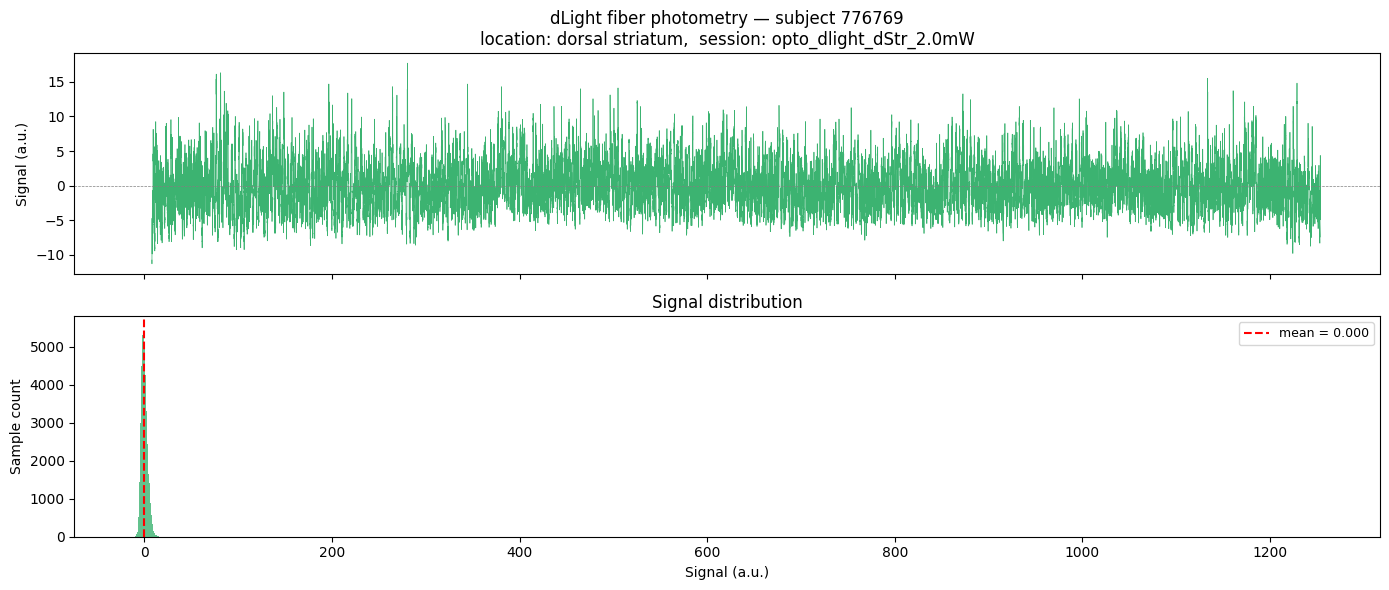

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Full signal trace
axes[0].plot(timestamps, signal, linewidth=0.5, color="mediumseagreen")
axes[0].set_ylabel("Signal (a.u.)")
axes[0].set_title(
    f"dLight fiber photometry — subject {nwbfile.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile.session_id}"
)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Signal distribution
axes[1].hist(signal, bins=50, color="mediumseagreen", edgecolor="none", alpha=0.8)
axes[1].axvline(np.mean(signal), color="red", linestyle="--", label=f"mean = {np.mean(signal):.3f}")
axes[1].set_xlabel("Signal (a.u.)")
axes[1].set_ylabel("Sample count")
axes[1].set_title("Signal distribution")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2. Optogenetic stimulation

The optogenetic TTL data is stored as an `OptogeneticSeries` in `stimulus/`. Values represent
laser power in **watts**: the session's intensity when the laser is on, 0 when off.

- **Target:** Bilateral SNc dopamine neurons (Anxa1-Flp mice expressing ChR2)
- **Wavelength:** 473 nm
- **Protocol:** 40 Hz laser, 1 s stimulation per nosepoke, 3 s inter-stimulation interval
- **Intensities tested:** 0.1, 0.2, 0.5, 1, 2 mW

**Note:** The first TTL burst corresponds to fiber photometry system activation and has been
excluded. All remaining bursts are nosepoke-triggered stimulation episodes.

In [5]:
ogen = nwbfile.stimulus["OptogeneticSeries"]
ogen_data = ogen.data[:]
ogen_rate = ogen.rate
ogen_start = ogen.starting_time
ogen_time = np.arange(len(ogen_data)) / ogen_rate + ogen_start

site = ogen.site
print(f"Site name:        {site.name}")
print(f"Location:         {site.location}")
print(f"Excitation λ:     {site.excitation_lambda} nm")
print(f"Site description: {site.description}")
print(f"\nSeries rate:      {ogen_rate:.2f} Hz")
print(f"Starting time:    {ogen_start:.3f} s")
print(f"Duration:         {len(ogen_data) / ogen_rate:.2f} s ({len(ogen_data)} samples)")
print(f"Unique values:    {sorted(set(ogen_data))} W  (0 = laser off, >0 = laser on)")
print(f"Intensity on:     {max(ogen_data) * 1000:.1f} mW  ({max(ogen_data):.4f} W)")

Site name:        OptogeneticStimulusSite
Location:         SNc
Excitation λ:     473.0 nm
Site description: Bilateral SNc optogenetic stimulation site. Laser frequency: 40.0 Hz, intensity: 2.0 mW.

Series rate:      142.82 Hz
Starting time:    14.468 s
Duration:         352.71 s (50375 samples)
Unique values:    [np.float64(0.0), np.float64(0.002)] W  (0 = laser off, >0 = laser on)
Intensity on:     2.0 mW  (0.0020 W)


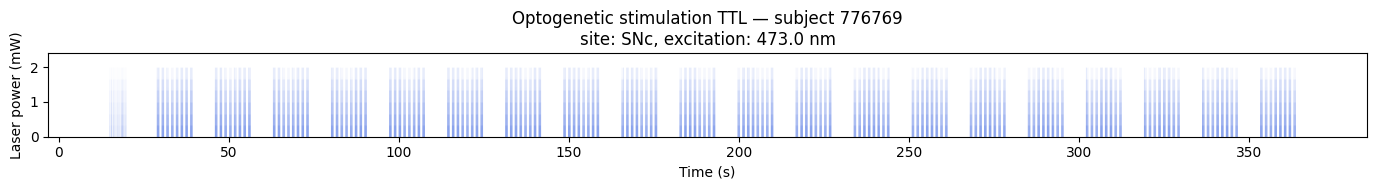

In [6]:
fig, ax = plt.subplots(figsize=(14, 2))

ax.fill_between(ogen_time, ogen_data * 1000, color="royalblue", alpha=0.8, linewidth=0)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Laser power (mW)")
ax.set_title(
    f"Optogenetic stimulation TTL — subject {nwbfile.subject.subject_id}\n"
    f"site: {site.location}, excitation: {site.excitation_lambda} nm"
)
ax.set_ylim(0, max(ogen_data) * 1000 * 1.2)

plt.tight_layout()
plt.show()

## 3. Stimulation episodes

Each nosepoke-triggered stimulation burst is stored as an interval in
`intervals/stimulation_episodes`. Each row records the onset and offset time of one 1-second
laser burst. The first TTL burst (fiber photometry activation) is excluded.

This `TimeIntervals` table allows easy peri-stimulus windowing of any other time series.

In [7]:
stim_episodes = nwbfile.intervals["stimulation_episodes"]
stim_df = stim_episodes.to_dataframe()

print(f"Total stimulation episodes: {len(stim_df)}")
print(f"\nFirst 5 episodes:")
print(stim_df.head())

# Compute episode durations and inter-stimulus intervals
durations = stim_df["stop_time"] - stim_df["start_time"]
isis = stim_df["start_time"].diff().dropna()  # inter-stimulus intervals

print(f"\nEpisode duration:   mean = {durations.mean():.3f} s,  std = {durations.std():.3f} s")
print(f"Inter-stim interval: mean = {isis.mean():.3f} s,  std = {isis.std():.3f} s")

Total stimulation episodes: 163

First 5 episodes:
    start_time  stop_time
id                       
0    15.457088  21.502592
1    22.543936  27.507507
2    28.586061  34.067174
3    76.466662  77.444365
4    80.468954  81.445171

Episode duration:   mean = 1.060 s,  std = 0.612 s
Inter-stim interval: mean = 7.588 s,  std = 9.570 s


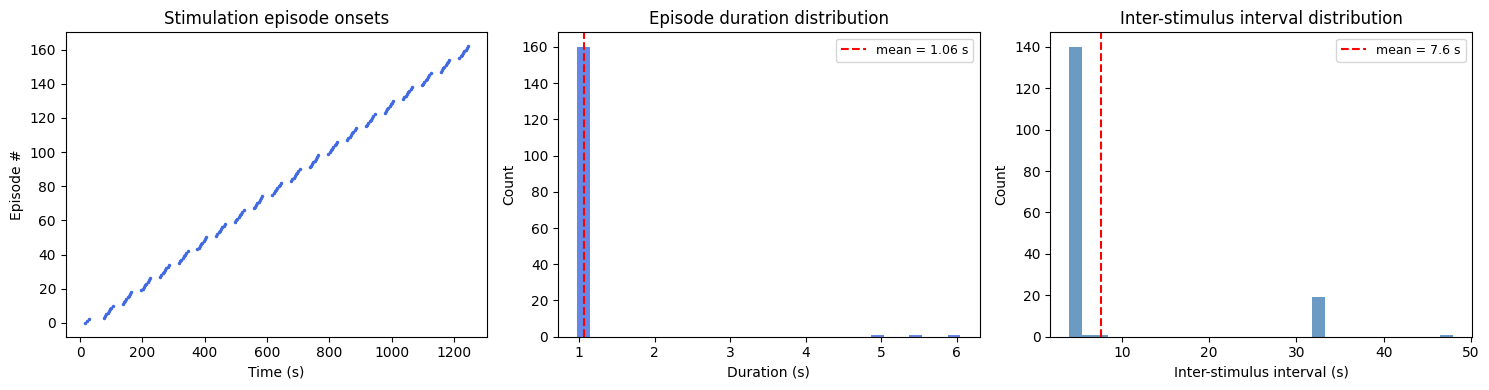

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Episode onset times over session
axes[0].plot(stim_df["start_time"], np.arange(len(stim_df)), ".", markersize=3, color="royalblue")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Episode #")
axes[0].set_title("Stimulation episode onsets")

# Duration distribution
axes[1].hist(durations, bins=30, color="royalblue", edgecolor="none", alpha=0.8)
axes[1].axvline(durations.mean(), color="red", linestyle="--", label=f"mean = {durations.mean():.2f} s")
axes[1].set_xlabel("Duration (s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Episode duration distribution")
axes[1].legend(fontsize=9)

# Inter-stimulus interval distribution
axes[2].hist(isis, bins=30, color="steelblue", edgecolor="none", alpha=0.8)
axes[2].axvline(isis.mean(), color="red", linestyle="--", label=f"mean = {isis.mean():.1f} s")
axes[2].set_xlabel("Inter-stimulus interval (s)")
axes[2].set_ylabel("Count")
axes[2].set_title("Inter-stimulus interval distribution")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Peri-stimulus dLight (triggered average)

Aligning the fiber photometry signal to stimulation onsets reveals the dopamine dynamics
triggered by nosepoke self-stimulation. The triggered average shows mean dopamine release
locked to the start of each 1-second laser burst.

**Note:** This analysis requires the full-session NWB file. The stub file only contains a
short segment of fiber photometry data (~5 s) that does not overlap with stimulation episodes
in this particular stub. Load a full-session file for meaningful peri-stimulus plots.

Trials extracted: 163 / 163 episodes


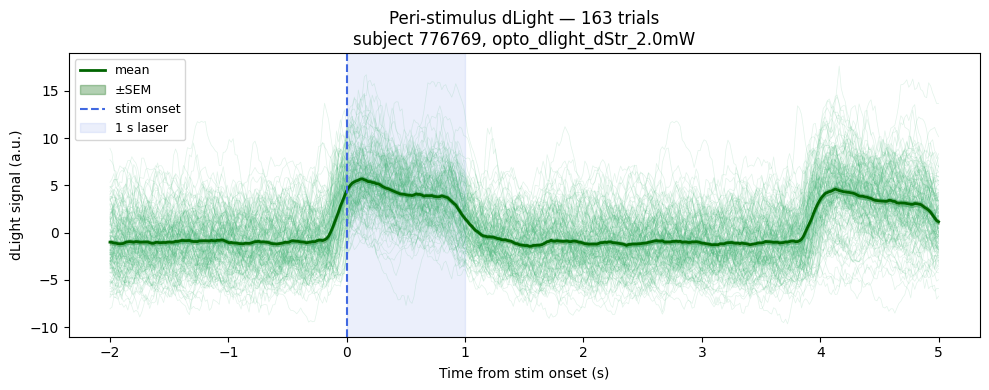

In [9]:
# Parameters
pre_s = 2.0   # seconds before stim onset
post_s = 5.0  # seconds after stim onset

fp_signal = nwbfile.acquisition["FiberPhotometryResponseSeries"].data[:]
fp_time = nwbfile.acquisition["FiberPhotometryResponseSeries"].timestamps[:]
stim_onsets = stim_df["start_time"].values

# Estimate sampling interval for interpolation
dt = np.median(np.diff(fp_time))
fs = 1.0 / dt
n_pre = int(pre_s * fs)
n_post = int(post_s * fs)
n_samples = n_pre + n_post

# Collect trials
trials = []
for onset in stim_onsets:
    t_start = onset - pre_s
    t_end = onset + post_s
    mask = (fp_time >= t_start) & (fp_time < t_end)
    if mask.sum() >= n_samples * 0.9:  # require at least 90% coverage
        # Interpolate to a regular grid
        t_grid = np.linspace(t_start, t_end, n_samples)
        snippet = np.interp(t_grid, fp_time[mask], fp_signal[mask])
        trials.append(snippet)

t_axis = np.linspace(-pre_s, post_s, n_samples)
print(f"Trials extracted: {len(trials)} / {len(stim_onsets)} episodes")

if len(trials) > 0:
    trials_arr = np.array(trials)
    mean_trace = trials_arr.mean(axis=0)
    sem_trace = trials_arr.std(axis=0) / np.sqrt(len(trials))

    fig, ax = plt.subplots(figsize=(10, 4))
    for trial in trials_arr:
        ax.plot(t_axis, trial, color="mediumseagreen", alpha=0.15, linewidth=0.5)
    ax.plot(t_axis, mean_trace, color="darkgreen", linewidth=2, label="mean")
    ax.fill_between(t_axis, mean_trace - sem_trace, mean_trace + sem_trace,
                    color="darkgreen", alpha=0.3, label="±SEM")
    ax.axvline(0, color="royalblue", linestyle="--", linewidth=1.5, label="stim onset")
    ax.axvspan(0, 1, color="royalblue", alpha=0.1, label="1 s laser")
    ax.set_xlabel("Time from stim onset (s)")
    ax.set_ylabel("dLight signal (a.u.)")
    ax.set_title(
        f"Peri-stimulus dLight — {len(trials)} trials\n"
        f"subject {nwbfile.subject.subject_id}, {nwbfile.session_id}"
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print(
        "No overlapping trials found — this is expected for the stub file.\n"
        "Load a full-session NWB file to see the peri-stimulus dLight response."
    )

## 5. NWB file structure overview

Summary of all containers in this NWB file.

In [10]:
print("=== Acquisition ===")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Stimulus ===")
for name, obj in nwbfile.stimulus.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Intervals ===")
for name, obj in nwbfile.intervals.items():
    df = obj.to_dataframe()
    print(f"  {name}: {type(obj).__name__} ({len(df)} rows)")

print("\n=== Lab metadata ===")
for name in nwbfile.lab_meta_data:
    print(f"  {name}")

print("\n=== Devices ===")
for name in nwbfile.devices:
    print(f"  {name}")

print("\n=== Subject ===")
s = nwbfile.subject
print(f"  subject_id: {s.subject_id}")
print(f"  species:    {s.species}")
print(f"  genotype:   {s.genotype}")
print(f"  strain:     {s.strain}")
print(f"  sex:        {s.sex}")

=== Acquisition ===
  FiberPhotometryResponseSeries: FiberPhotometryResponseSeries

=== Stimulus ===
  OptogeneticSeries: OptogeneticSeries

=== Intervals ===
  stimulation_episodes: TimeIntervals (163 rows)

=== Lab metadata ===
  fiber_photometry

=== Devices ===
  excitation_source
  laser
  optical_fiber
  photodetector

=== Subject ===
  subject_id: 776769
  species:    Mus musculus
  genotype:   anxa1-flp
  strain:     C57BL/6N
  sex:        U


In [11]:
io.close()